# 🎮 Personalized VALORANT Agent Recommendation System

## Notebook 01 — Exploratory Data Analysis

### Project Objective

The objective of this project is to develop a personalized machine-learning
system that recommends suitable VALORANT agents based on an individual player's
own Competitive match history.

This notebook analyzes my personal VALORANT gameplay history in order to
understand how my performance varies across different agents, maps, and
Agent × Map combinations.

The final system will take the current map as input and generate a ranked list
of the **Top 5–6 agents most suitable for me**, based on patterns learned from
my own previous matches.

The recommendation process is intended to consider factors such as:

- previous experience with each agent,
- historical performance with each agent,
- previous experience on the current map,
- historical Agent × Map performance,
- recent gameplay form,
- agent familiarity and usage frequency.

My dataset will be modeled independently from other players' datasets so that
the recommendations remain personalized to my own gameplay history.

This notebook focuses on the **Exploratory Data Analysis (EDA)** stage of the
project.

### Current Dataset

- Game Mode: Competitive
- Total Matches: 296
- Data Period: November 2024 to September 2026
- Dataset Source: My personal VALORANT Competitive match history
- Data Type: Tabular
- Total Original Features: 22

### Goals of This Notebook

1. Inspect the structure and overall quality of my Competitive match dataset.
2. Identify missing values, duplicate records, and unusual match entries.
3. Study the distribution of wins, losses, and draws.
4. Analyze which agents I play most frequently and measure my level of agent
   familiarity.
5. Analyze the distribution of matches across different VALORANT maps.
6. Examine my overall gameplay-performance statistics.
7. Compare my historical performance across different agents.
8. Compare my historical performance across different maps.
9. Analyze specific Agent × Map combinations to determine whether my performance
   with an agent changes depending on the map.
10. Identify sparse Agent × Map combinations where limited match history may make
    performance estimates unreliable.
11. Examine relationships between match statistics and match outcomes.
12. Detect unusual values, surrender matches, overtime matches, and other
    non-standard match endings.
13. Identify which existing variables can later be transformed into historical
    pre-match features without introducing data leakage.
14. Prepare the dataset for chronological feature engineering and personalized
    machine-learning modelling.

### Future Goal

The final goal is to build a personalized map-based VALORANT agent
recommendation system.

When the current map is known, the system will evaluate the agents I have
historical experience with and return a ranked list of my **Top 5–6 recommended
agents**.

The recommendation will be based only on information that would have been
available before the target match, including historical features such as:

- recent 5-match and 10-match form,
- previous agent usage and familiarity,
- previous win rate and performance with each agent,
- previous map experience and map performance,
- previous Agent × Map experience and performance,
- number of previous matches played with an agent,
- number of previous matches played on a map,
- recency and frequency of agent usage.

Current-match statistics such as K/D, ACS, DDΔ, kills, deaths, TRS, and final
score will not be used directly for pre-match recommendations because they are
only known during or after the match.

Instead, historical versions of these statistics will be calculated using only
matches that occurred before each target match.

The recommendation model will therefore learn my individual gameplay profile
rather than producing the same agent ranking for every player.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
DATA_PATH = Path("../data/competitive_matches.xlsx")

df = pd.read_excel(
    DATA_PATH,
    sheet_name="Matches",
    header=1,
    usecols="A:V"
)

df.head()

,Match id,Date,Map,Placement,Agent,Team Score,Opponent Score,Result,Win Flag,Score Margin,...,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ (Average Damage Delta per Round),HS% (Headshot Percentage),ACS (Average Combat Score),TRS (Tracker Score)
0,1,2024-11-07,Sunset,6th,Sage,8,13,Loss,0.0,-5,...,16,3,1.000000,0.761905,0.761905,0.142857,-11,0.10,210,578
1,2,2024-11-07,Split,9th,Clove,5,13,Loss,0.0,-8,...,9,2,0.777778,0.388889,0.500000,0.111111,-9,0.10,117,172
2,3,2024-11-08,Pearl,4th,Clove,13,10,Win,1.0,3,...,15,2,1.333333,0.869565,0.652174,0.086957,19,0.09,229,728
3,4,2024-11-08,Sunset,3rd,Sage,9,11,Loss,0.0,-2,...,15,6,0.933333,0.700000,0.750000,0.300000,11,0.05,237,475
4,5,2024-11-09,Haven,7th,Clove,4,13,Loss,0.0,-9,...,16,2,0.562500,0.529412,0.941176,0.117647,-51,0.10,163,146


In [48]:
df = df.rename(columns={
    "DDΔ (Average Damage Delta per Round)": "DDΔ",
    "HS% (Headshot Percentage)": "HS%",
    "ACS (Average Combat Score)": "ACS",
    "TRS (Tracker Score)": "TRS"
})

In [49]:
print("Number of matches:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nColumns:\n")
for column in df.columns:
    print(column)

Number of matches: 297
Number of features: 22

Columns:

Match id
Date
Map
Placement
Agent
Team Score
Opponent Score
Result
Win Flag
Score Margin
Rounds Played
Kills
Deaths
Assists
K/D
Kills/Round
Deaths/Round
Assists/Round
DDΔ
HS%
ACS
TRS


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Match id        297 non-null    int64         
 1   Date            297 non-null    datetime64[us]
 2   Map             297 non-null    str           
 3   Placement       297 non-null    str           
 4   Agent           297 non-null    str           
 5   Team Score      297 non-null    int64         
 6   Opponent Score  297 non-null    int64         
 7   Result          297 non-null    str           
 8   Win Flag        287 non-null    float64       
 9   Score Margin    297 non-null    int64         
 10  Rounds Played   297 non-null    int64         
 11  Kills           297 non-null    int64         
 12  Deaths          297 non-null    int64         
 13  Assists         297 non-null    int64         
 14  K/D             297 non-null    float64       
 15  Kills/Round     2

In [51]:
df.isnull().sum()

Match id           0
Date               0
Map                0
Placement          0
Agent              0
Team Score         0
Opponent Score     0
Result             0
Win Flag          10
Score Margin       0
Rounds Played      0
Kills              0
Deaths             0
Assists            0
K/D                0
Kills/Round        0
Deaths/Round       0
Assists/Round      0
DDΔ                0
HS%                0
ACS                0
TRS                0
dtype: int64

In [52]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate Match id values:",
    df["Match id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Match id values: 0


In [53]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

print(
    "Oldest match:",
    df["Date"].min()
)

print(
    "Newest match:",
    df["Date"].max()
)

datetime64[us]
Oldest match: 2024-11-07 00:00:00
Newest match: 2026-09-20 00:00:00


In [54]:
print("========================")
print("Maps:")
print(df["Map"].value_counts())
print("========================")
print("\nAgents:")
print(df["Agent"].value_counts())
print("========================")
print("\nResults:")
print(df["Result"].value_counts())

Maps:
Map
Haven       42
Ascent      39
Lotus       39
Split       38
Pearl       34
Sunset      24
Icebox      21
Fracture    17
Bind        16
Abyss       15
Breeze       5
Summit       4
Corrode      3
Name: count, dtype: int64

Agents:
Agent
Sage        161
Clove        58
Killjoy      30
Breach       17
Deadlock     10
Skye          9
Fade          5
Astra         4
Reyna         3
Name: count, dtype: int64

Results:
Result
Loss    149
Win     138
Draw     10
Name: count, dtype: int64


In [55]:
result_counts = df["Result"].value_counts()

print(result_counts)

Result
Loss    149
Win     138
Draw     10
Name: count, dtype: int64


In [56]:
result_percentages = (
    df["Result"]
    .value_counts(normalize=True)
    * 100
)

print(result_percentages.round(2))

Result
Loss    50.17
Win     46.46
Draw     3.37
Name: proportion, dtype: float64


In [57]:
df.describe()

,Match id,Date,Team Score,Opponent Score,Win Flag,Score Margin,Rounds Played,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS,TRS
count,297.000000,297,297.000000,297.000000,287.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,149.000000,2025-06-27 01:12:43.636363,9.946128,10.060606,0.480836,-0.114478,20.006734,11.158249,13.845118,5.198653,0.910113,0.561123,0.687505,0.257725,-28.441077,0.071010,160.053872,427.198653
min,1.000000,2024-11-07 00:00:00,0.000000,0.000000,0.000000,-13.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.133333,0.000000,-136.000000,0.000000,14.000000,100.000000
25%,75.000000,2025-03-08 00:00:00,7.000000,7.000000,0.000000,-6.000000,17.000000,7.000000,11.000000,3.000000,0.550000,0.380952,0.578947,0.153846,-58.000000,0.040000,114.000000,239.000000
50%,149.000000,2025-04-18 00:00:00,12.000000,13.000000,0.000000,-2.000000,20.000000,11.000000,14.000000,5.000000,0.769231,0.541667,0.695652,0.250000,-30.000000,0.060000,155.000000,412.000000
75%,223.000000,2025-07-21 00:00:00,13.000000,13.000000,1.000000,5.000000,23.000000,14.000000,17.000000,7.000000,1.142857,0.722222,0.809524,0.347826,-4.000000,0.090000,198.000000,587.000000
max,297.000000,2026-09-20 00:00:00,15.000000,15.000000,1.000000,13.000000,30.000000,32.000000,24.000000,13.000000,4.500000,1.391304,1.066667,0.750000,129.000000,0.330000,409.000000,976.000000
std,85.880731,NaN,3.852490,3.939110,0.500505,6.543541,4.230674,5.521323,4.501079,2.836347,0.612585,0.253065,0.172187,0.131836,45.367092,0.044891,66.352639,233.154160


In [58]:
print(df.columns.tolist())

['Match id', 'Date', 'Map', 'Placement', 'Agent', 'Team Score', 'Opponent Score', 'Result', 'Win Flag', 'Score Margin', 'Rounds Played', 'Kills', 'Deaths', 'Assists', 'K/D', 'Kills/Round', 'Deaths/Round', 'Assists/Round', 'DDΔ', 'HS%', 'ACS', 'TRS']


In [59]:
total_matches = len(df)

wins = (df["Result"] == "Win").sum()
losses = (df["Result"] == "Loss").sum()
draws = (df["Result"] == "Draw").sum()

win_rate = wins / total_matches

total_kills = df["Kills"].sum()
total_deaths = df["Deaths"].sum()

overall_kd = total_kills / total_deaths

average_acs = df["ACS"].mean()
average_hs = df["HS%"].mean()

print("=== OVERALL PERFORMANCE ===")

print(f"Matches: {total_matches}")
print(f"Wins: {wins}")
print(f"Losses: {losses}")
print(f"Draws: {draws}")

print(f"Win Rate: {win_rate:.2%}")
print(f"Overall K/D: {overall_kd:.2f}")
print(f"Average ACS: {average_acs:.2f}")
print(f"Average HS%: {average_hs:.2%}")

=== OVERALL PERFORMANCE ===
Matches: 297
Wins: 138
Losses: 149
Draws: 10
Win Rate: 46.46%
Overall K/D: 0.81
Average ACS: 160.05
Average HS%: 7.10%


**WIN VS LOSS VS DRAW**

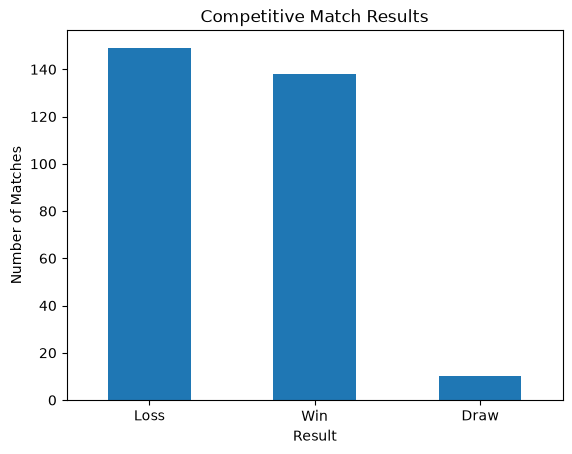

In [60]:
df["Result"].value_counts().plot(
    kind="bar",
    title="Competitive Match Results"
)

plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.show()

**MATCHES PLAYED BY AGENTS**

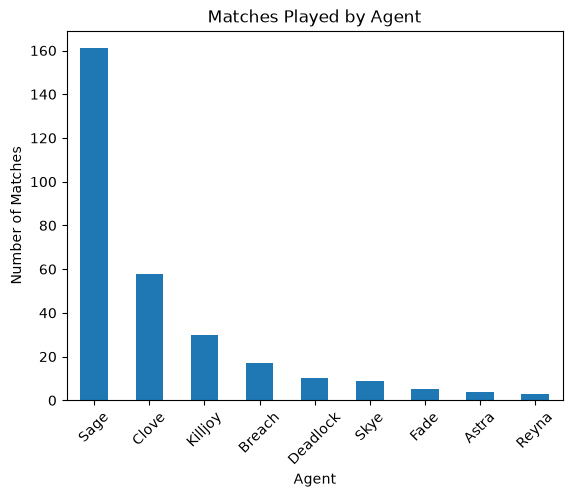

In [61]:
df["Agent"].value_counts().plot(
    kind="bar",
    title="Matches Played by Agent"
)

plt.xlabel("Agent")
plt.ylabel("Number of Matches")

plt.xticks(
    rotation=45
)

plt.show()

**MATCHES PLAYED ON MAPS**

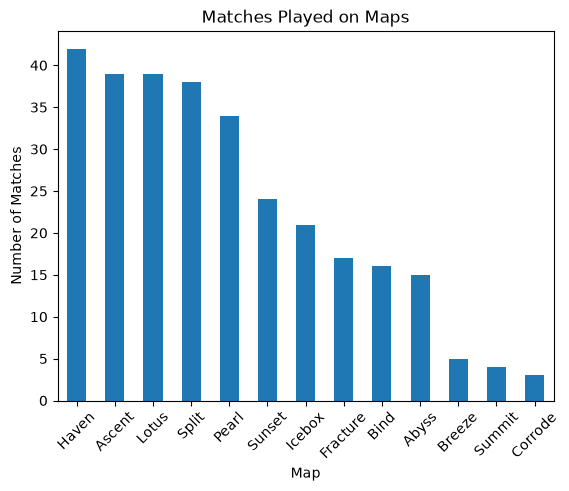

In [62]:
df["Map"].value_counts().plot(
    kind="bar",
    title="Matches Played on Maps"
)

plt.xlabel("Map")
plt.ylabel("Number of Matches")

plt.xticks(
    rotation=45
)

plt.show()

<!-- # Initial EDA Findings

The Competitive dataset contains 294 matches recorded
between November 2024 and September 2026.

## Dataset Quality

- No duplicate matches were detected.
- Agent and map information is complete.
- Ten Win Flag values are missing because the corresponding
  matches were recorded as draws.
- Several matches have non-standard final scores, potentially
  representing early match termination and requiring further
  investigation.

## Match Outcomes

- Wins: 135
- Losses: 149
- Draws: 10

The Win/Loss distribution is reasonably balanced.

## Agent Distribution

The dataset is strongly dominated by Sage matches.
Agents such as Astra, Reyna, and Fade have much smaller
sample sizes and should therefore be interpreted cautiously.

## Performance

Overall K/D is approximately 0.80 and average ACS is
approximately 159.5.

Matches that were won show substantially higher average K/D
than lost matches.

## ML Considerations

Current-match performance variables such as K/D, ACS,
DDΔ and TRS are post-match variables and must not be used
directly for pre-match prediction.

Future modelling will instead use historical versions of
these features calculated only from matches played before
the target match. -->

## Performance by Agent

This section compares historical performance across the different
agents played in Competitive matches.

Because the number of matches played with each agent is different,
sample size must be considered when interpreting metrics such as
win rate and K/D.

In [63]:
agent_stats = (
    df.groupby("Agent")
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
)

agent_stats["Win_Rate"] = (
    agent_stats["Wins"] / agent_stats["Matches"]
)

agent_stats["Overall_KD"] = (
    agent_stats["Kills"] / agent_stats["Deaths"]
)

agent_stats.sort_values(
    "Matches",
    ascending=False
).round(2)

,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
Agent,,,,,,,,,,
Sage,161,72.0,1738,2157,950,155.96,0.07,-30.55,0.45,0.81
Clove,58,27.0,696,919,250,167.45,0.08,-35.78,0.47,0.76
Killjoy,30,19.0,362,389,132,169.57,0.07,-8.77,0.63,0.93
Breach,17,9.0,184,223,64,157.47,0.06,-22.94,0.53,0.83
Deadlock,10,1.0,101,141,33,156.30,0.06,-33.70,0.10,0.72
Skye,9,3.0,92,121,45,145.89,0.07,-38.67,0.33,0.76
Fade,5,2.0,68,80,41,199.20,0.11,-8.20,0.40,0.85
Astra,4,4.0,43,47,19,153.75,0.14,-2.50,1.00,0.91
Reyna,3,1.0,30,35,10,154.67,0.04,-21.67,0.33,0.86


## Performance by Map

This section compares my historical Competitive performance across
different VALORANT maps.

Metrics such as win rate, overall K/D, ACS and damage delta are used
to identify map-specific performance patterns.

In [64]:
map_stats = (
    df.groupby("Map")
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
)

map_stats["Win_Rate"] = (
    map_stats["Wins"] / map_stats["Matches"]
)

map_stats["Overall_KD"] = (
    map_stats["Kills"] / map_stats["Deaths"]
)

map_stats.sort_values(
    "Matches",
    ascending=False
).round(2)

,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
Map,,,,,,,,,,
Haven,42,22.0,487,582,203,164.69,0.07,-23.31,0.52,0.84
Lotus,39,14.0,431,527,202,160.10,0.07,-30.79,0.36,0.82
Ascent,39,19.0,467,505,211,177.92,0.07,-16.79,0.49,0.92
Split,38,23.0,402,495,203,150.18,0.07,-24.55,0.61,0.81
Pearl,34,16.0,330,476,185,139.12,0.07,-36.53,0.47,0.69
Sunset,24,8.0,299,363,128,177.12,0.07,-35.00,0.33,0.82
Icebox,21,9.0,231,310,120,155.48,0.09,-31.05,0.43,0.75
Fracture,17,11.0,165,211,75,136.29,0.05,-32.41,0.65,0.78
Bind,16,7.0,177,231,71,160.75,0.07,-33.06,0.44,0.77


## Agent × Map Analysis

This section analyzes performance for specific Agent–Map combinations.

-to understand whether my performance changes depending on
which agent I play on a particular map because some Agent–Map combinations have very few matches, sample size
must be considered before interpreting win rate or performance metrics.

In [65]:
agent_map_stats = (
    df.groupby(["Map", "Agent"])
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
    .reset_index()
)

agent_map_stats["Win_Rate"] = (
    agent_map_stats["Wins"] / agent_map_stats["Matches"]
)

agent_map_stats["Overall_KD"] = (
    agent_map_stats["Kills"] / agent_map_stats["Deaths"]
)

agent_map_stats.sort_values(
    "Matches",
    ascending=False
).head(20).round(2)

,Map,Agent,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
57,Split,Sage,25,16.0,273,316,154,156.68,0.07,-23.20,0.64,0.86
44,Lotus,Sage,25,8.0,287,350,141,159.32,0.08,-32.56,0.32,0.82
10,Ascent,Sage,22,11.0,226,271,122,157.73,0.08,-24.73,0.50,0.83
32,Haven,Sage,22,8.0,219,284,106,150.91,0.07,-31.77,0.36,0.77
52,Pearl,Sage,18,7.0,174,227,110,143.56,0.07,-32.61,0.39,0.77
39,Icebox,Sage,14,6.0,150,216,93,156.71,0.07,-40.71,0.43,0.69
62,Sunset,Sage,11,5.0,152,161,78,189.45,0.05,-19.00,0.45,0.94
30,Haven,Clove,11,6.0,151,177,48,179.91,0.08,-27.00,0.55,0.85
60,Sunset,Clove,9,1.0,104,155,31,167.78,0.09,-61.22,0.11,0.67
27,Fracture,Sage,8,5.0,75,96,43,121.62,0.03,-40.50,0.62,0.78


## K/D Distribution

This section examines the distribution of K/D ratios across all
Competitive matches.

The purpose is to understand the typical range of K/D values,
identify unusually high or low performances, and observe whether
the distribution is concentrated around a particular range.

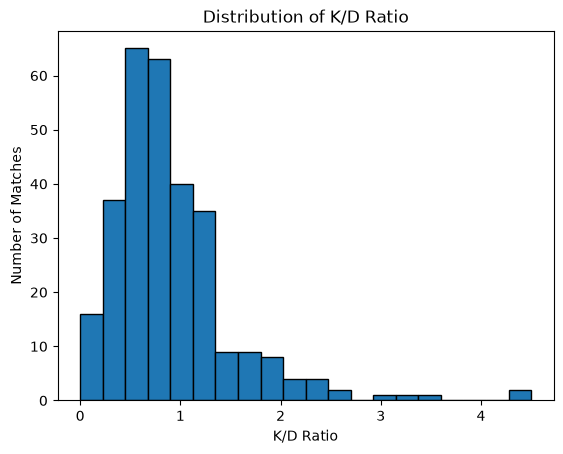

In [66]:
plt.hist(
    df["K/D"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of K/D Ratio")
plt.xlabel("K/D Ratio")
plt.ylabel("Number of Matches")

plt.show()

In [67]:
print("Average K/D:", round(df["K/D"].mean(), 2))
print("Median K/D:", round(df["K/D"].median(), 2))
print("Minimum K/D:", round(df["K/D"].min(), 2))
print("Maximum K/D:", round(df["K/D"].max(), 2))

Average K/D: 0.91
Median K/D: 0.77
Minimum K/D: 0.0
Maximum K/D: 4.5


## ACS Distribution

This section examines the distribution of Average Combat Score (ACS)
across all Competitive matches.

The goal is to understand the typical ACS range, identify unusually
high or low performances, and observe how combat performance is
distributed across the dataset.

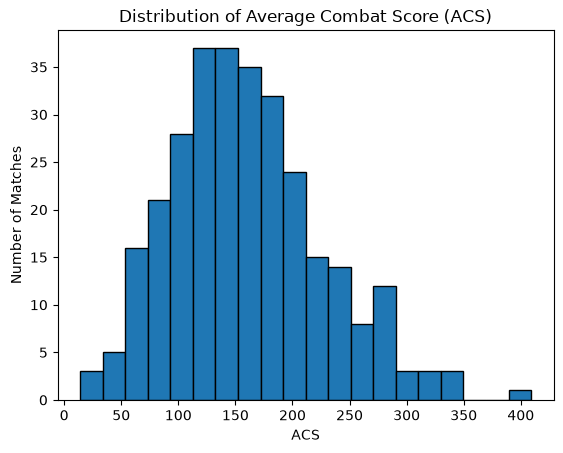

In [68]:
plt.hist(
    df["ACS"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Average Combat Score (ACS)")
plt.xlabel("ACS")
plt.ylabel("Number of Matches")

plt.show()

In [69]:
print("Average ACS:", round(df["ACS"].mean(), 2))
print("Median ACS:", round(df["ACS"].median(), 2))
print("Minimum ACS:", df["ACS"].min())
print("Maximum ACS:", df["ACS"].max())

Average ACS: 160.05
Median ACS: 155.0
Minimum ACS: 14
Maximum ACS: 409


## DDΔ Distribution

This section examines the distribution of Average Damage Delta per Round (DDΔ)
across all Competitive matches.

DDΔ represents the difference between damage dealt and damage received per round.

Positive DDΔ values indicate that more damage was dealt than received,
while negative values indicate that more damage was received than dealt.

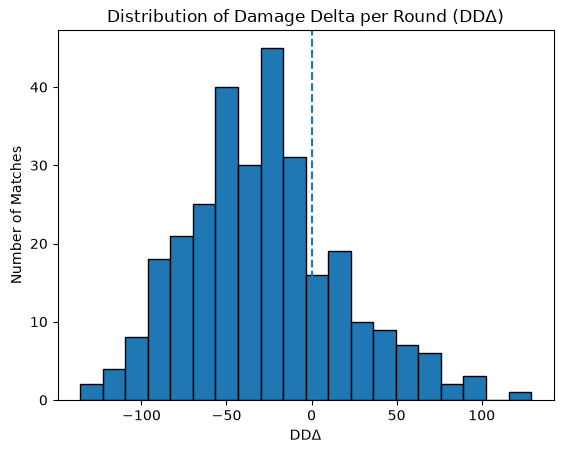

In [70]:
plt.hist(
    df["DDΔ"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Damage Delta per Round (DDΔ)")
plt.xlabel("DDΔ")
plt.ylabel("Number of Matches")

plt.show()

In [71]:
print("Average DDΔ:", round(df["DDΔ"].mean(), 2))
print("Median DDΔ:", round(df["DDΔ"].median(), 2))
print("Minimum DDΔ:", df["DDΔ"].min())
print("Maximum DDΔ:", df["DDΔ"].max())

Average DDΔ: -28.44
Median DDΔ: -30.0
Minimum DDΔ: -136
Maximum DDΔ: 129


## Wins vs Losses Comparison

This section compares performance metrics between matches that were won
and matches that were lost.

The purpose is to identify which performance statistics tend to differ
between wins and losses.

These relationships are descriptive and do not necessarily imply causation.

In [72]:
result_performance = (
    df.groupby("Result")
    .agg(
        Avg_KD=("K/D", "mean"),
        Avg_ACS=("ACS", "mean"),
        Avg_DD=("DDΔ", "mean"),
        Avg_Kills=("Kills", "mean"),
        Avg_Deaths=("Deaths", "mean"),
        Avg_Assists=("Assists", "mean"),
        Avg_TRS=("TRS", "mean")
    )
)

result_performance.round(2)

,Avg_KD,Avg_ACS,Avg_DD,Avg_Kills,Avg_Deaths,Avg_Assists,Avg_TRS
Result,,,,,,,
Draw,0.76,159.90,-38.00,15.30,20.10,8.20,424.20
Loss,0.68,156.03,-46.46,10.42,15.46,4.57,299.16
Win,1.17,164.41,-8.30,11.66,11.65,5.66,565.66


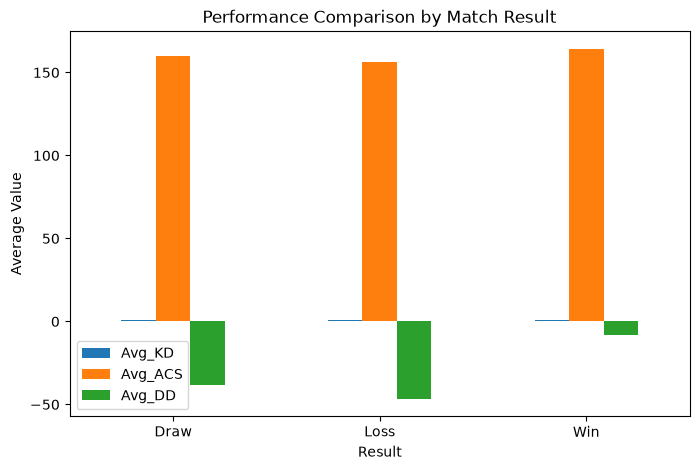

In [73]:
result_performance[
    ["Avg_KD", "Avg_ACS", "Avg_DD"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Performance Comparison by Match Result")
plt.xlabel("Result")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

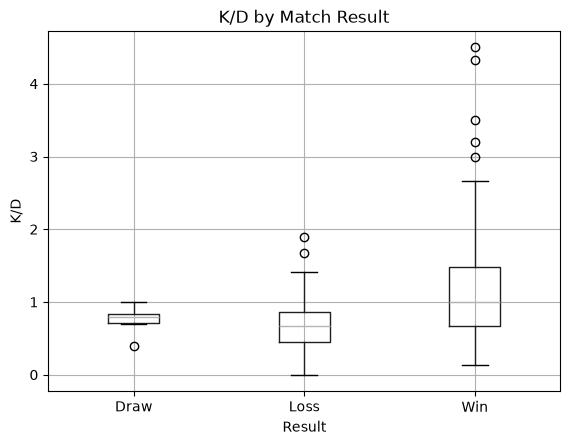

In [74]:
df.boxplot(
    column="K/D",
    by="Result"
)

plt.title("K/D by Match Result")
plt.suptitle("")
plt.xlabel("Result")
plt.ylabel("K/D")

plt.show()

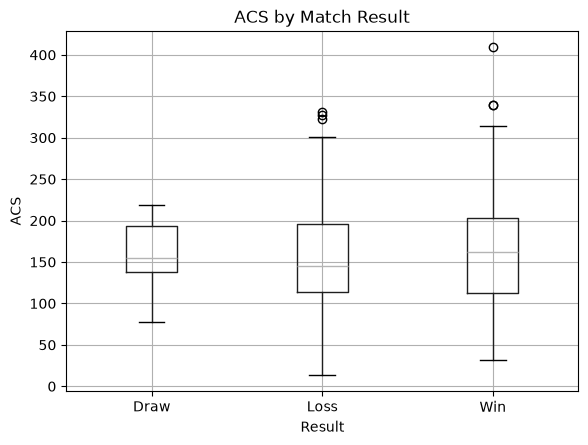

In [75]:
df.boxplot(
    column="ACS",
    by="Result"
)

plt.title("ACS by Match Result")
plt.suptitle("")
plt.xlabel("Result")
plt.ylabel("ACS")

plt.show()

## Correlation

This section examines the relationships between numerical features in
the Competitive match dataset.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate little or no linear relationship.

Special attention is given to correlations with the Win Flag in order
to identify performance metrics that are associated with match outcomes.

Correlation does not imply causation.

In [76]:
numeric_columns = [
    "Win Flag",
    "Kills",
    "Deaths",
    "Assists",
    "K/D",
    "Kills/Round",
    "Deaths/Round",
    "Assists/Round",
    "DDΔ",
    "HS%",
    "ACS",
    "TRS"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(2)

,Win Flag,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS,TRS
Win Flag,1.00,0.11,-0.43,0.19,0.39,0.14,-0.61,0.24,0.42,-0.01,0.06,0.56
Kills,0.11,1.00,0.20,0.23,0.56,0.88,-0.05,0.10,0.67,0.08,0.86,0.69
Deaths,-0.43,0.20,1.00,0.20,-0.52,-0.13,0.74,-0.07,-0.46,-0.02,-0.05,-0.37
Assists,0.19,0.23,0.20,1.00,0.02,0.05,-0.10,0.92,0.13,-0.08,0.11,0.24
K/D,0.39,0.56,-0.52,0.02,1.00,0.73,-0.61,0.09,0.83,0.13,0.65,0.79
Kills/Round,0.14,0.88,-0.13,0.05,0.73,1.00,-0.11,0.06,0.78,0.09,0.97,0.78
Deaths/Round,-0.61,-0.05,0.74,-0.10,-0.61,-0.11,1.00,-0.17,-0.56,-0.05,0.00,-0.51
Assists/Round,0.24,0.10,-0.07,0.92,0.09,0.06,-0.17,1.00,0.18,-0.12,0.11,0.28
DDΔ,0.42,0.67,-0.46,0.13,0.83,0.78,-0.56,0.18,1.00,0.13,0.77,0.89
HS%,-0.01,0.08,-0.02,-0.08,0.13,0.09,-0.05,-0.12,0.13,1.00,0.04,0.06


In [77]:
win_correlations = (
    correlation_matrix["Win Flag"]
    .drop("Win Flag")
    .sort_values(ascending=False)
)

win_correlations.round(2)

TRS              0.56
DDΔ              0.42
K/D              0.39
Assists/Round    0.24
Assists          0.19
Kills/Round      0.14
Kills            0.11
ACS              0.06
HS%             -0.01
Deaths          -0.43
Deaths/Round    -0.61
Name: Win Flag, dtype: float64

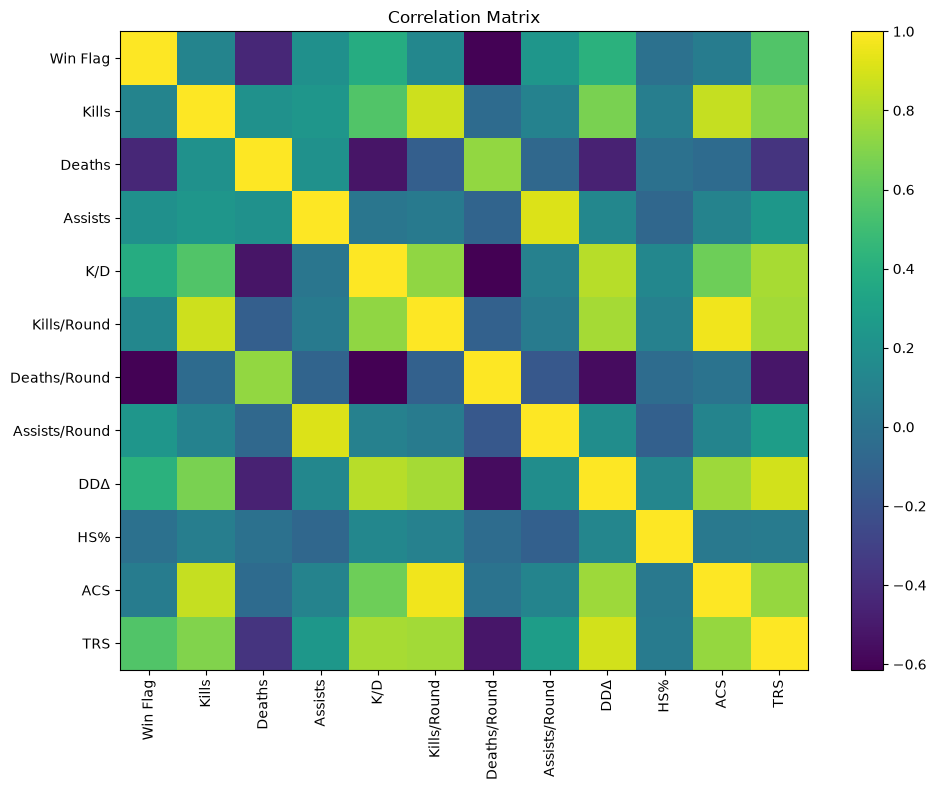

In [78]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Outlier Analysis

This section investigates unusually high or low values in important
performance metrics such as K/D, ACS and DDΔ.

Outliers are examined to determine whether they represent valid extreme
performances or possible data-quality issues.

Outliers are not removed automatically.

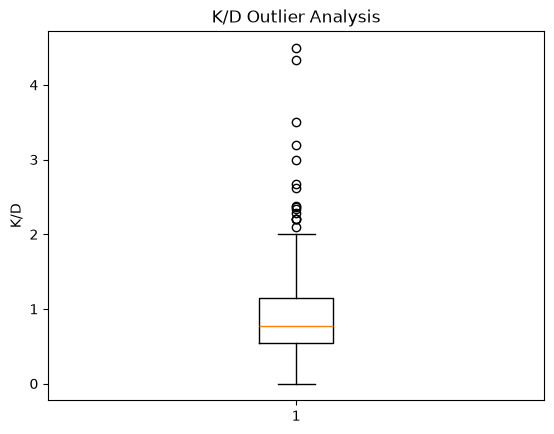

In [79]:
plt.boxplot(df["K/D"])

plt.title("K/D Outlier Analysis")
plt.ylabel("K/D")

plt.show()

Highest k/d matches

In [80]:
df.sort_values(
    "K/D",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
117,2025-03-30,Ascent,Sage,9,2,4.500000,182,65
139,2025-04-15,Ascent,Killjoy,13,3,4.333333,290,77
62,2025-02-24,Pearl,Sage,7,2,3.500000,128,45
255,2026-08-11,Ascent,Clove,16,5,3.200000,277,73
148,2025-04-18,Icebox,Astra,3,1,3.000000,81,13
285,2026-08-30,Haven,Sage,32,12,2.666667,409,129
250,2026-08-08,Sunset,Sage,21,8,2.625000,248,44
251,2026-08-08,Haven,Clove,19,8,2.375000,314,90
275,2026-08-27,Sunset,Sage,26,11,2.363636,302,84
162,2025-04-27,Split,Killjoy,21,9,2.333333,237,70


Lowest k/d matches

In [81]:
df.sort_values(
    "K/D",
    ascending=True
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
58,2025-02-22,Pearl,Deadlock,0,18,0.000000,14,-136
137,2025-04-12,Pearl,Killjoy,2,15,0.133333,32,-83
201,2025-06-20,Icebox,Sage,3,22,0.136364,47,-100
37,2025-01-11,Split,Sage,2,12,0.166667,69,-87
35,2025-01-08,Pearl,Sage,3,18,0.166667,46,-114
80,2025-03-11,Split,Sage,3,17,0.176471,74,-88
47,2025-02-19,Fracture,Sage,2,11,0.181818,62,-113
145,2025-04-16,Haven,Sage,2,11,0.181818,53,-82
166,2025-05-03,Pearl,Sage,3,16,0.187500,88,-81
225,2025-07-23,Ascent,Clove,3,16,0.187500,92,-81


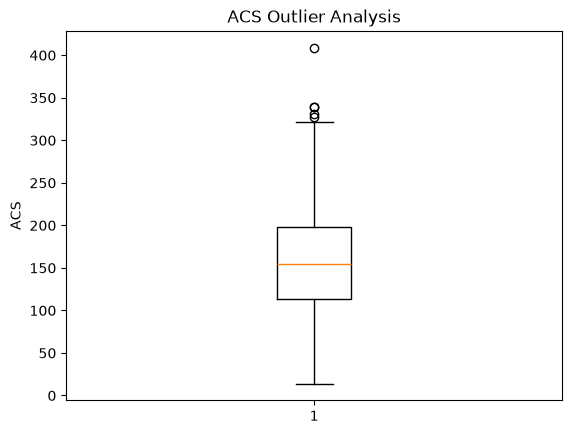

In [82]:
plt.boxplot(df["ACS"])

plt.title("ACS Outlier Analysis")
plt.ylabel("ACS")

plt.show()

In [83]:
df.sort_values(
    "ACS",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
285,2026-08-30,Haven,Sage,32,12,2.666667,409,129
127,2025-04-07,Haven,Killjoy,26,16,1.625000,339,102
274,2026-08-27,Haven,Sage,22,10,2.200000,339,60
271,2026-08-25,Haven,Sage,6,5,1.200000,331,21
273,2026-08-26,Lotus,Sage,25,15,1.666667,327,14
258,2026-08-12,Sunset,Sage,20,16,1.250000,322,38
251,2026-08-08,Haven,Clove,19,8,2.375000,314,90
275,2026-08-27,Sunset,Sage,26,11,2.363636,302,84
22,2024-12-03,Bind,Clove,28,23,1.217391,301,24
246,2025-08-29,Bind,Clove,14,16,0.875000,293,-19


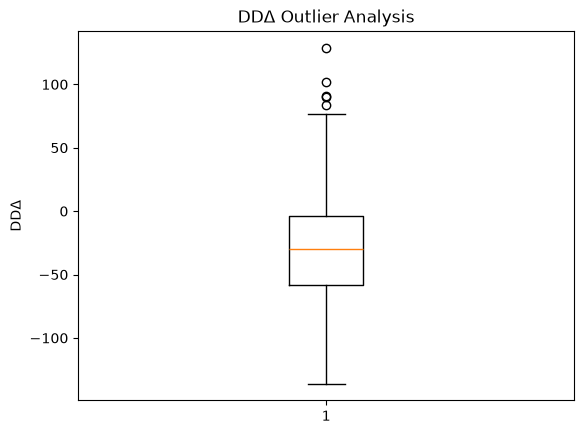

In [84]:
plt.boxplot(df["DDΔ"])

plt.title("DDΔ Outlier Analysis")
plt.ylabel("DDΔ")

plt.show()

In [85]:
df.sort_values(
    "DDΔ",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
285,2026-08-30,Haven,Sage,32,12,2.666667,409,129
127,2025-04-07,Haven,Killjoy,26,16,1.625000,339,102
119,2025-03-30,Pearl,Breach,24,13,1.846154,289,91
251,2026-08-08,Haven,Clove,19,8,2.375000,314,90
275,2026-08-27,Sunset,Sage,26,11,2.363636,302,84
139,2025-04-15,Ascent,Killjoy,13,3,4.333333,290,77
255,2026-08-11,Ascent,Clove,16,5,3.200000,277,73
206,2025-06-23,Icebox,Sage,22,11,2.000000,261,71
199,2025-06-20,Split,Sage,16,7,2.285714,258,70
162,2025-04-27,Split,Killjoy,21,9,2.333333,237,70


## Match Score Validation and Match Ending Type

This section validates Competitive match scores and identifies how each
match ended.

Matches may end through:

- Regulation
- Overtime
- Overtime Draw
- Surrender

Some matches therefore have scores below the standard 13-round winning
threshold because one of the teams surrendered before the match was
completed normally.

For surrendered matches:

- If Team Score > Opponent Score, the opponent team surrendered.
- If Opponent Score > Team Score, my team surrendered.

These matches are valid observations and are retained in the dataset.

In [86]:
def classify_match_end(team_score, opponent_score, result):

    high = max(team_score, opponent_score)
    low = min(team_score, opponent_score)

    # Overtime Draw
    if result == "Draw":
        if team_score == opponent_score and team_score >= 13:
            return "Overtime Draw"

        return "Review"

    # Regulation ending
    if high == 13 and low <= 11:
        return "Regulation"

    # Overtime ending
    if high >= 14 and low >= 12 and (high - low) == 2:
        return "Overtime"

    # A Win/Loss with a non-standard final score
    # indicates that the match ended through surrender
    if result in ["Win", "Loss"]:
        return "Surrender"

    return "Review"

In [87]:
df["Match End Type"] = df.apply(
    lambda row: classify_match_end(
        row["Team Score"],
        row["Opponent Score"],
        row["Result"]
    ),
    axis=1
)

df["Match End Type"].value_counts()

Match End Type
Regulation       244
Overtime          24
Surrender         19
Overtime Draw     10
Name: count, dtype: int64

In [88]:
def surrendered_by(row):

    if row["Match End Type"] != "Surrender":
        return None

    if row["Result"] == "Win":
        return "Opponent Team"

    if row["Result"] == "Loss":
        return "My Team"

    return "Unknown"


df["Surrendered By"] = df.apply(
    surrendered_by,
    axis=1
)

In [89]:
df["Surrendered By"].value_counts()

Surrendered By
My Team          10
Opponent Team     9
Name: count, dtype: int64

In [90]:
df[
    df["Match End Type"] == "Surrender"
][
    [
        "Match id",
        "Date",
        "Map",
        "Agent",
        "Team Score",
        "Opponent Score",
        "Result",
        "Surrendered By"
    ]
]

,Match id,Date,Map,Agent,Team Score,Opponent Score,Result,Surrendered By
3,4,2024-11-08,Sunset,Sage,9,11,Loss,My Team
8,9,2024-11-10,Ascent,Sage,10,3,Win,Opponent Team
18,19,2024-11-24,Pearl,Reyna,3,11,Loss,My Team
27,28,2024-12-27,Ascent,Sage,7,7,Win,Opponent Team
30,31,2025-01-06,Split,Sage,1,8,Loss,My Team
54,55,2025-02-21,Bind,Sage,9,8,Win,Opponent Team
57,58,2025-02-22,Split,Sage,4,9,Loss,My Team
60,61,2025-02-23,Bind,Deadlock,3,10,Loss,My Team
91,92,2025-03-16,Ascent,Sage,0,6,Loss,My Team
95,96,2025-03-17,Ascent,Sage,2,6,Loss,My Team


# Initial EDA Findings

The exploratory data analysis was performed on **296 personal VALORANT Competitive matches**
recorded between **7 November 2024 and 20 September 2026**.

## Dataset Quality

- The dataset contains **296 matches and 22 original features**.
- No duplicate rows or duplicate Match IDs were detected.
- Agent, map, score, and performance-statistic fields are complete.
- The `Win Flag` column contains **10 missing values**, corresponding to the 10 drawn matches rather than missing data.
- Match dates were successfully converted into chronological datetime values.
- Final-score analysis identified:
  - **243 Regulation matches**
  - **24 Overtime matches**
  - **19 Surrendered matches**
  - **10 Overtime Draws**
- Among surrendered matches, **10 were surrendered by my team** and **9 by the opponent team**.

One initially unusual match ended at a score of **7–7**. Inspection of the
original match history confirmed that the opponent team surrendered, so the
match was corrected from a Draw to a Win and classified as a Surrender.

This observation also demonstrated that the final score alone cannot always
identify which team surrendered. The recorded match result is therefore used
when identifying the surrendering team.

Surrendered matches are treated as valid Competitive observations rather than
erroneous score records.

## Match Outcome Distribution

The 296 matches consist of:

- **137 Wins**
- **149 Losses**
- **10 Draws**

The overall recorded win rate is approximately **46.28%**.

Wins and losses are reasonably balanced, which is useful for future binary
classification after deciding how draws should be handled.

## Agent Distribution

The dataset is strongly dominated by a small number of frequently played agents.

The most frequently played agents are:

- **Sage: 160 matches**
- **Clove: 58 matches**
- **Killjoy: 30 matches**
- **Breach: 17 matches**

Several agents have very small sample sizes, including Astra, Reyna, and Fade.
Their performance statistics should therefore be interpreted cautiously.

Among agents with comparatively larger sample sizes:

- Sage has a historical win rate of approximately **44%**
- Clove has a historical win rate of approximately **47%**
- Killjoy has a historical win rate of approximately **63%**
- Breach has a historical win rate of approximately **53%**

Raw win rates should not be interpreted as proof that one agent is inherently
better because the number of matches, maps played, time period, and other match
conditions differ.

## Map Distribution

The most frequently played maps include:

- **Haven: 41 matches**
- **Ascent: 39 matches**
- **Lotus: 39 matches**
- **Split: 38 matches**
- **Pearl: 34 matches**

Some newer or less frequently encountered maps contain much smaller sample sizes.

Among the better represented maps:

- Split has a historical win rate of approximately **61%**
- Haven has a historical win rate of approximately **51%**
- Ascent has a historical win rate of approximately **49%**
- Lotus has a historical win rate of approximately **36%**

These results indicate that performance may differ across maps and support the
inclusion of map-related historical features in later modelling.

## Agent × Map Patterns

Performance also varies across specific Agent–Map combinations.

Some of the combinations with the largest sample sizes are:

- Sage on Split: **25 matches**, approximately **64% win rate**
- Sage on Lotus: **25 matches**, approximately **32% win rate**
- Sage on Ascent: **22 matches**, approximately **50% win rate**
- Sage on Haven: **21 matches**, approximately **33% win rate**
- Sage on Pearl: **18 matches**, approximately **39% win rate**

These results show why agent and map should not only be analyzed independently.
Their interaction may contain useful information for the future personalized
agent-recommendation system.

However, Agent–Map combinations with only a few observations must be interpreted
cautiously because extreme win rates from small samples may not be reliable.

## Overall Performance

Across the complete Competitive dataset:

- Overall aggregated K/D is approximately **0.80**
- Mean per-match K/D is approximately **0.91**
- Median per-match K/D is approximately **0.77**
- Average ACS is approximately **159.99**
- Average Headshot Percentage is approximately **7.09%**
- Average DDΔ is approximately **-28.57**

The per-match K/D ranges from:

- Minimum: **0.00**
- Maximum: **4.50**

ACS ranges from **14 to 409**, while DDΔ ranges from **-136 to +129**.

These extreme observations appear to represent unusually strong or weak matches
rather than automatically indicating incorrect data, so they are retained for
further analysis.

## Wins vs Losses

Clear descriptive differences were observed between wins and losses.

Average performance in wins:

- K/D: approximately **1.17**
- ACS: approximately **164.30**
- DDΔ: approximately **-8.42**
- Kills: approximately **11.64**
- Deaths: approximately **11.65**
- Assists: approximately **5.68**
- TRS: approximately **565.36**

Average performance in losses:

- K/D: approximately **0.68**
- ACS: approximately **156.03**
- DDΔ: approximately **-46.46**
- Kills: approximately **10.42**
- Deaths: approximately **15.46**
- Assists: approximately **4.57**
- TRS: approximately **299.16**

This suggests that stronger combat-performance statistics are associated with
winning in this dataset.

These relationships are descriptive and should not be interpreted as evidence
of causation.

## Correlation Findings

Among the numerical variables, the strongest observed correlations with
`Win Flag` include:

### Positive Correlations

- TRS: approximately **+0.56**
- DDΔ: approximately **+0.41**
- K/D: approximately **+0.39**
- Assists/Round: approximately **+0.24**
- Assists: approximately **+0.20**

### Negative Correlations

- Deaths: approximately **-0.43**
- Deaths/Round: approximately **-0.61**

This indicates that matches with higher TRS, DDΔ, and K/D tend to be associated
with wins, while higher death-related values tend to be associated with losses.

Again, correlation represents association rather than causation.

## Important Machine-Learning Consideration

Variables describing the current match, such as:

- K/D
- ACS
- DDΔ
- TRS
- Kills
- Deaths
- Assists
- Team Score
- Opponent Score
- Score Margin
- Match End Type

are only known during or after the match has already been played.

Therefore, these variables must **not** be used directly as predictors in a
model intended to make recommendations or predictions before a match, as doing
so would introduce **data leakage**.

Instead, future feature engineering will create historical features using only
information available before each target match, such as:

- Recent 5-match win rate
- Recent 10-match win rate
- Recent K/D
- Recent ACS
- Previous performance with the selected agent
- Previous performance on the selected map
- Previous Agent × Map performance
- Number of previous matches played with an agent
- Number of previous matches played on a map
- Number of previous matches played with an agent on a specific map

## EDA Conclusion

The dataset is sufficiently structured and informative to proceed to the next
stage of the project.

The analysis suggests that **recent performance, agent experience, map
experience, and Agent × Map interaction** are promising areas for feature
engineering.

The next stage will focus on **data cleaning and historical feature engineering**,
ensuring that only information available before each target match is used for
machine-learning prediction.